In [0]:
from databricks.connect import DatabricksSession

spark = DatabricksSession.builder.getOrCreate()

In [0]:
from datetime import date, timedelta

import pyspark.sql.functions as F
from pyspark.sql import Column
from pyspark.sql import DataFrame, SparkSession
from pyspark.sql.window import Window

def get_customer(spark: SparkSession, customer_shortname: str) -> DataFrame:
    """Customers/operators/publishers are identified with different ids accross the tables."""
    customers = (
        spark.table("mirakl_ai.ds_etl_prod.t2s_gold_customer")
        .where(F.col("shortName") == customer_shortname)
        .select("shortName", "publicId", F.col("databaseName").alias("db_name"))
    )

    publishers = (
        spark.table("mirakl_data_platform.prod_data_platform_silver.artemis_insights_customer").alias("I")
        .join(
            spark.table("mirakl_data_platform.prod_data_platform_silver. artemis_publisher").alias("P"),
            F.col("P.insights_customer_id") == F.col("I.id"),
            "left",
        )
        .where(F.col("I.__k8s_namespace") == "artemis-prod")
        .select(F.col("P.id").alias("publisherId"), F.col("I.public_id").alias("public_id"))
    )

    return (
        customers.join(publishers, customers.publicId == publishers.public_id, "inner")
        .select(
            F.col("shortName").alias("customer_shortname"),
            F.col("publicId").alias("customerId"),
            "db_name",
            "publisherId"
        )
    )

def get_products(spark: SparkSession, db_names: list[str]) -> DataFrame:
    """Loads the catalog of active master products (parent id = -1). To be used to get more features."""
    return (
        spark.table("mirakl_ai.ds_etl_prod.t2s_mongo_product_0_current")
        .filter(
            F.col("db_name").isin(db_names)
            & F.col("isActive")
            & F.col("isOkInStream")
            & (F.col("parentId") == -1)
        )
        .select(
            F.col("internalId").cast("bigint").alias("internalId"),
            "fwProductId",
            "name",
            "imageUrl"
        )
    )

def get_views(spark: SparkSession, customer_ids: list[str], start_date: date, end_date: date) -> DataFrame:
    """Loads raw tracking. Not cleaned. Merged user is used to reconcilate users ids."""
    df_merged_user = (
        spark.table("mirakl_data_platform.prod_data_platform_silver.t2s_merged_user")
        .filter(F.col("customerId").isin(customer_ids))
        .select(
            F.col("masterId").alias("userMasterId"),
            F.col("sourceId").alias("userId"),
        )
    )

    return (
        spark.table("mirakl_data_platform.prod_data_platform_silver.t2s_tracking_product_display_page_event_fct")
        .filter(
            F.col("customerId").isin(customer_ids)
            & F.col("emitted").between(start_date, end_date)
            & F.col("user.internalId").isNotNull()
            & F.col("masterProductInternalId").isNotNull()
        )
        .withColumnRenamed("masterProductInternalId", "internalId")
        .withColumn("userId", F.col("user.internalId"))
        .join(df_merged_user, on="userId", how="left")
        .withColumn("userId", F.coalesce(F.col("userMasterId"), F.col("userId")))
        .select(
            "emitted", # timestamp of the event
            "internalId", # product internalId
            "userId", # only used for aggregation, doesn't carry meaning
        )
    )

def sessionize_views(df_views: DataFrame, session_timeout: int = 1800) -> DataFrame:
    """Split user views into sessions based on an inactivity timeout. Returns views enriched with a session_id and session_start timestamp."""
    user_window = Window.partitionBy("userId").orderBy("emitted")

    df = df_views.withColumn(
        "seconds_since_last", 
        (F.col("emitted") - F.lag("emitted").over(user_window)).cast("long")
    )

    df = df.withColumn(
        "is_new_session",
        F.when(
            F.col("seconds_since_last").isNull() | (F.col("seconds_since_last") > session_timeout),
            F.lit(1)
        ).otherwise(F.lit(0))
    )

    df = df.withColumn(
        "session_id",
        F.sum("is_new_session").over(user_window.rowsBetween(Window.unboundedPreceding, Window.currentRow))
    )

    session_window = Window.partitionBy("userId", "session_id")
    df = df.withColumn(
        "session_start",
        F.min("emitted").over(session_window)
    )

    return df.select("userId", "session_id", "internalId", "emitted", "session_start")

def split_sessions(df_sessionized: DataFrame, cutoff_train: date, cutoff_val: date) -> DataFrame:
    """Split sessions into train/val/test based on hard date cutoffs.

    session_start <  cutoff_train  -> train
    cutoff_train <= session_start <  cutoff_val  -> val
    cutoff_val   <= session_start                -> test
    """
    df_sessions = df_sessionized.select("userId", "session_id", "session_start").distinct()

    df_sessions = df_sessions.withColumn(
        "split",
        F.when(F.col("session_start") < F.lit(cutoff_train), F.lit("train"))
        .when(F.col("session_start") < F.lit(cutoff_val), F.lit("val"))
        .otherwise(F.lit("test"))
    )

    return df_sessionized.join(
        df_sessions.select("userId", "session_id", "split"),
        on=["userId", "session_id"],
        how="inner",
    )

USE_SESSION_WEIGHT_NORM = False

def build_co_view_edges(df_sessionized: DataFrame) -> DataFrame:
    """Generate co-view edges from sessionized views. Returns pairs of products seen in the same session with their co-occurrence count."""
    df_dedup = df_sessionized.select("userId", "session_id", "internalId").distinct()

    session_sizes = (
        df_dedup
        .groupBy("userId", "session_id")
        .agg(F.countDistinct("internalId").alias("session_size"))
    )

    df_dedup = df_dedup.join(session_sizes, on=["userId", "session_id"], how="inner")

    df_pairs = (
        df_dedup.alias("L")
        .join(
            df_dedup.alias("R"),
            on=(
                (F.col("L.userId") == F.col("R.userId"))
                & (F.col("L.session_id") == F.col("R.session_id"))
                & (F.col("L.internalId") < F.col("R.internalId"))
            ),
            how="inner"
        )
        .select(
            F.col("L.internalId").alias("product_A"),
            F.col("R.internalId").alias("product_B"),
            (
                (F.lit(1.0) / (F.col("L.session_size") - F.lit(1)))
                if USE_SESSION_WEIGHT_NORM
                else F.lit(1.0)
            ).alias("pair_weight"),
        )
    )

    return df_pairs.groupBy("product_A", "product_B").agg(
        F.sum("pair_weight").alias("weight"),
        F.count("*").alias("raw_count"),
    )

def remove_train_edges(df_edges: DataFrame, df_train_edges: DataFrame) -> DataFrame:
    """Remove from df_edges any pair already present in df_train_edges."""
    return df_edges.join(
        df_train_edges.select("product_A", "product_B"),
        on=["product_A", "product_B"],
        how="left_anti"
    )

def dedup_views(df_views: DataFrame, min_gap_seconds: int = 30) -> DataFrame:
    """Remove duplicate views of the same product by the same user within a short time window."""
    w = Window.partitionBy("userId", "internalId").orderBy("emitted")
    return (
        df_views
        .withColumn(
            "gap",
            F.unix_timestamp("emitted") - F.unix_timestamp(F.lag("emitted").over(w))
        )
        .filter(F.col("gap").isNull() | (F.col("gap") > min_gap_seconds))
        .drop("gap")
    )

def filter_users(df_views: DataFrame, min_views: int = 3, max_views: int = 5000) -> DataFrame:
    """Keep only users with a reasonable number of views."""
    user_counts = df_views.groupBy("userId").agg(F.count("*").alias("n_views"))
    valid_users = user_counts.filter(
        (F.col("n_views") >= min_views) & (F.col("n_views") <= max_views)
    ).select("userId")
    return df_views.join(valid_users, on="userId", how="inner")

def filter_sessions(df_sessionized: DataFrame, min_size: int = 2, max_size: int = 50) -> DataFrame:
    """Remove sessions that are too small (no pairs) or too large (combinatorial explosion)."""
    session_sizes = (
        df_sessionized
        .groupBy("userId", "session_id")
        .agg(F.countDistinct("internalId").alias("session_size"))
        .filter(
            (F.col("session_size") >= min_size) & (F.col("session_size") <= max_size)
        )
        .select("userId", "session_id")
    )
    return df_sessionized.join(session_sizes, on=["userId", "session_id"], how="inner")

def filter_edges(df_edges: DataFrame, min_weight: int = 2) -> DataFrame:
    """Keep only edges with enough co-occurrences to be meaningful."""
    return df_edges.filter(F.col("weight") >= min_weight)

In [0]:
import pandas as pd
import matplotlib.pyplot as plt

def explore_dedup_views(df_views: DataFrame, bucket_size: int = 10, cap: int = 3600, min_gap_seconds: int = 30):
    w = Window.partitionBy("userId", "internalId").orderBy("emitted")

    df_views_gap = df_views.withColumn(
        "gap",
        F.unix_timestamp("emitted") - F.unix_timestamp(F.lag("emitted").over(w))
    ).filter(F.col("gap").isNotNull())

    df_buckets = df_views_gap.withColumn(
        "gap_bucket",
        (F.floor(F.least(F.col("gap"), F.lit(cap)) / bucket_size) * bucket_size).cast("int")
    )

    df_pd = (
        df_buckets
        .groupBy("gap_bucket")
        .count()
        .orderBy("gap_bucket")
        .toPandas()
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Linear scale
    df_zoom = df_pd[df_pd["gap_bucket"] <= 300]
    axes[0].bar(df_zoom["gap_bucket"], df_zoom["count"], width=bucket_size * 0.9)
    axes[0].axvline(x=min_gap_seconds, color="red", linestyle="--", label=f"seuil = {min_gap_seconds}s")
    axes[0].set_title("Distribution des gaps (zoom 0-300s)")
    axes[0].set_xlabel("Gap (secondes)")
    axes[0].set_ylabel("Nombre de vues")
    axes[0].legend()

    # Log scale
    axes[1].bar(df_pd["gap_bucket"], df_pd["count"], width=bucket_size * 0.9)
    axes[1].axvline(x=min_gap_seconds, color="red", linestyle="--", label=f"seuil = {min_gap_seconds}s")
    axes[1].set_yscale("log")
    axes[1].set_title("Distribution des gaps (log scale, vue complète)")
    axes[1].set_xlabel("Gap (secondes)")
    axes[1].set_ylabel("Nombre de vues (log)")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

def explore_filter_users(df_views: DataFrame, min_views: int = 3, max_views: int = 5000, bucket_size: int = 10, cap: int = 500):
    
    # Étape 1 : n_views par user
    user_counts = (
        df_views
        .groupBy("userId")
        .agg(F.count("*").alias("n_views"))
    )

    # Étape 2 : stats pour calibrer les seuils
    quantiles = user_counts.approxQuantile("n_views", [0.5, 0.9, 0.95, 0.99, 1.0], 0.01)
    stats = user_counts.select(
        F.min("n_views").alias("min"),
        F.max("n_views").alias("max"),
        F.mean("n_views").alias("mean"),
        F.count("*").alias("total_users"),
    ).first()

    print("=" * 40)
    print(f"Total users       : {stats['total_users']:,}")
    print(f"Min n_views       : {stats['min']}")
    print(f"Max n_views       : {stats['max']}")
    print(f"Mean n_views      : {stats['mean']:.1f}")
    print(f"Percentile  50%   : {quantiles[0]}")
    print(f"Percentile  90%   : {quantiles[1]}")
    print(f"Percentile  95%   : {quantiles[2]}")
    print(f"Percentile  99%   : {quantiles[3]}")
    print(f"Percentile 100%   : {quantiles[4]}")
    print("=" * 40)

    # Étape 3 : buckets linéaires avec cap
    user_counts_bucketed = user_counts.withColumn(
        "n_views_bucket",
        (F.floor(F.least(F.col("n_views"), F.lit(cap)) / bucket_size) * bucket_size).cast("int")
    )

    df_pd = (
        user_counts_bucketed
        .groupBy("n_views_bucket")
        .agg(F.count("*").alias("n_users"))
        .orderBy("n_views_bucket")
        .toPandas()
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # --- Plot 1 : linéaire, zoom sur les petits counts ---
    df_zoom = df_pd[df_pd["n_views_bucket"] <= 100]
    axes[0].bar(df_zoom["n_views_bucket"], df_zoom["n_users"], width=bucket_size * 0.9)
    axes[0].axvline(x=min_views, color="red", linestyle="--", label=f"min_views = {min_views}")
    axes[0].axvline(x=max_views, color="orange", linestyle="--", label=f"max_views = {max_views}")
    axes[0].set_title("Distribution n_views par user (zoom 0-100)")
    axes[0].set_xlabel("Nombre de vues")
    axes[0].set_ylabel("Nombre d'users")
    axes[0].legend()

    # --- Plot 2 : log Y, vue complète bornée au cap ---
    axes[1].bar(df_pd["n_views_bucket"], df_pd["n_users"], width=bucket_size * 0.9)
    axes[1].axvline(x=min_views, color="red", linestyle="--", label=f"min_views = {min_views}")
    axes[1].axvline(x=max_views, color="orange", linestyle="--", label=f"max_views = {max_views}")
    axes[1].set_yscale("log")
    axes[1].set_xlim(0, cap)
    axes[1].set_title("Distribution n_views par user (log Y, vue complète)")
    axes[1].set_xlabel("Nombre de vues")
    axes[1].set_ylabel("Nombre d'users (log)")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

def explore_filter_sessions(df_sessionized: DataFrame, min_size: int = 2, max_size: int = 50):

    session_counts = (
        df_sessionized
        .groupBy("userId", "session_id")
        .agg(F.countDistinct("internalId").alias("session_size"))
    )

    quantiles = session_counts.approxQuantile("session_size", [0.5, 0.9, 0.95, 0.99, 1.0], 0.01)
    stats = session_counts.select(
        F.min("session_size").alias("min"),
        F.max("session_size").alias("max"),
        F.mean("session_size").alias("mean"),
        F.count("*").alias("total_sessions"),
    ).first()

    print("=" * 40)
    print(f"Total sessions    : {stats['total_sessions']:,}")
    print(f"Min session_size  : {stats['min']}")
    print(f"Max session_size  : {stats['max']}")
    print(f"Mean session_size : {stats['mean']:.1f}")
    print(f"Percentile  50%   : {quantiles[0]}")
    print(f"Percentile  90%   : {quantiles[1]}")
    print(f"Percentile  95%   : {quantiles[2]}")
    print(f"Percentile  99%   : {quantiles[3]}")
    print(f"Percentile 100%   : {quantiles[4]}")
    print("=" * 40)

    df_pd = (
        session_counts
        .groupBy("session_size")
        .agg(F.count("*").alias("n_sessions"))
        .orderBy("session_size")
        .toPandas()
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # --- Plot 1 : linéaire, zoom sur les petites sessions ---
    df_zoom = df_pd[df_pd["session_size"] <= 20]
    axes[0].bar(df_zoom["session_size"], df_zoom["n_sessions"], width=0.9)
    axes[0].axvline(x=min_size, color="red", linestyle="--", label=f"min_size = {min_size}")
    axes[0].axvline(x=max_size, color="orange", linestyle="--", label=f"max_size = {max_size}")
    axes[0].set_title("Distribution session_size (zoom 0-20)")
    axes[0].set_xlabel("Nombre de produits distincts")
    axes[0].set_ylabel("Nombre de sessions")
    axes[0].legend()

    # --- Plot 2 : log Y, vue complète ---
    axes[1].bar(df_pd["session_size"], df_pd["n_sessions"], width=0.9)
    axes[1].axvline(x=min_size, color="red", linestyle="--", label=f"min_size = {min_size}")
    axes[1].axvline(x=max_size, color="orange", linestyle="--", label=f"max_size = {max_size}")
    axes[1].set_yscale("log")
    axes[1].set_title("Distribution session_size (log Y, vue complète)")
    axes[1].set_xlabel("Nombre de produits distincts")
    axes[1].set_ylabel("Nombre de sessions (log)")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


def explore_filter_edges(df_edges: DataFrame, min_weight: int = 2, bucket_size: int = 1, cap: int = 50):

    # Étape 1 : stats pour calibrer les seuils
    quantiles = df_edges.approxQuantile("weight", [0.5, 0.9, 0.95, 0.99, 1.0], 0.01)
    stats = df_edges.select(
        F.min("weight").alias("min"),
        F.max("weight").alias("max"),
        F.mean("weight").alias("mean"),
        F.count("*").alias("total_edges"),
    ).first()

    print("=" * 40)
    print(f"Total edges       : {stats['total_edges']:,}")
    print(f"Min weight        : {stats['min']}")
    print(f"Max weight        : {stats['max']}")
    print(f"Mean weight       : {stats['mean']:.1f}")
    print(f"Percentile  50%   : {quantiles[0]}")
    print(f"Percentile  90%   : {quantiles[1]}")
    print(f"Percentile  95%   : {quantiles[2]}")
    print(f"Percentile  99%   : {quantiles[3]}")
    print(f"Percentile 100%   : {quantiles[4]}")
    print("=" * 40)

    # Étape 2 : buckétisation avec cap
    df_bucketed = df_edges.withColumn(
        "weight_bucket",
        (F.floor(F.least(F.col("weight"), F.lit(cap)) / bucket_size) * bucket_size).cast("int")
    )

    df_pd = (
        df_bucketed
        .groupBy("weight_bucket")
        .agg(F.count("*").alias("n_edges"))
        .orderBy("weight_bucket")
        .toPandas()
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # --- Plot 1 : linéaire, zoom sur les petits weights ---
    df_zoom = df_pd[df_pd["weight_bucket"] <= 20]
    axes[0].bar(df_zoom["weight_bucket"], df_zoom["n_edges"], width=bucket_size * 0.9)
    axes[0].axvline(x=min_weight, color="red", linestyle="--", label=f"min_weight = {min_weight}")
    axes[0].set_title("Distribution des weights (zoom 0-20)")
    axes[0].set_xlabel("Weight (co-occurrences)")
    axes[0].set_ylabel("Nombre d'arêtes")
    axes[0].legend()

    # --- Plot 2 : log Y, vue complète bornée au cap ---
    axes[1].bar(df_pd["weight_bucket"], df_pd["n_edges"], width=bucket_size * 0.9)
    axes[1].axvline(x=min_weight, color="red", linestyle="--", label=f"min_weight = {min_weight}")
    axes[1].set_yscale("log")
    axes[1].set_xlim(0, cap)
    axes[1].set_title("Distribution des weights (log Y, vue complète)")
    axes[1].set_xlabel("Weight (co-occurrences)")
    axes[1].set_ylabel("Nombre d'arêtes (log)")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


def explore_isolated_nodes_by_degree(df_edges: DataFrame, min_weight: int = 2, min_bucket_count: int = 10):
    """% de nœuds isolés après filter_edges (weight >= min_weight), conditionné au degré original.

    Permet de voir si le filtre élimine surtout les nœuds faiblement connectés (sain),
    ou si des hubs perdent toutes leurs edges (signal de bruit sur des produits "promiscuous").
    """

    # Degré original : union des deux endpoints pour compter chaque edge sur ses 2 noeuds
    df_degrees = (
        df_edges.select(F.col("product_A").alias("node"))
        .union(df_edges.select(F.col("product_B").alias("node")))
        .groupBy("node")
        .agg(F.count("*").alias("degree_original"))
    )

    # Degré après application du filtre
    df_filtered = df_edges.filter(F.col("weight") >= min_weight)
    df_degrees_after = (
        df_filtered.select(F.col("product_A").alias("node"))
        .union(df_filtered.select(F.col("product_B").alias("node")))
        .groupBy("node")
        .agg(F.count("*").alias("degree_after"))
    )

    # Jointure + marquage des isolés (degree_after = 0)
    df_node = (
        df_degrees.join(df_degrees_after, on="node", how="left")
        .withColumn("degree_after", F.coalesce(F.col("degree_after"), F.lit(0)))
        .withColumn("is_isolated", (F.col("degree_after") == 0).cast("int"))
    )

    # Bucketisation logarithmique du degré original
    df_node = df_node.withColumn(
        "degree_bucket_idx",
        F.floor(F.log2(F.col("degree_original"))).cast("int")
    )

    # Agrégation par bucket
    df_pd = (
        df_node
        .groupBy("degree_bucket_idx")
        .agg(
            F.count("*").alias("total_nodes"),
            F.sum("is_isolated").alias("isolated_nodes"),
        )
        .orderBy("degree_bucket_idx")
        .toPandas()
    )

    # Mask des buckets trop peu peuplés (sinon % trompeur sur 1-2 noeuds)
    df_pd = df_pd[df_pd["total_nodes"] >= min_bucket_count].copy()

    df_pd["pct_isolated"] = df_pd["isolated_nodes"] / df_pd["total_nodes"] * 100

    def bucket_label(idx):
        if idx == 0:
            return "1"
        return f"{2**idx}-{2**(idx+1) - 1}"

    df_pd["bucket_label"] = df_pd["degree_bucket_idx"].map(bucket_label)

    fig, ax = plt.subplots(figsize=(10, 5))

    bars = ax.bar(df_pd["bucket_label"], df_pd["pct_isolated"])

    # Annotation : isolated/total brut au-dessus de chaque barre
    for bar, isolated, total in zip(bars, df_pd["isolated_nodes"], df_pd["total_nodes"]):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 1,
            f"{int(isolated)}/{int(total)}",
            ha="center",
            va="bottom",
            fontsize=8,
        )

    ax.set_title(f"% de nœuds isolés après filter_edges (min_weight = {min_weight})")
    ax.set_xlabel("Degré original (bucket log2)")
    ax.set_ylabel("% de nœuds devenus isolés")
    ax.set_ylim(0, 105)
    ax.axhline(y=50, color="gray", linestyle="--", linewidth=0.8)

    plt.tight_layout()
    plt.show()


def plot_final_degree_distribution(df_edges: DataFrame, cap: int = 200):
    """Distribution des degrés sur les nœuds restants après tous les filtres + split.

    df_edges doit être l'union NON-symétrisée des splits (chaque paire A<B une fois).
    Le degré est calculé en sommant les apparitions du nœud en tant que product_A
    OU product_B, ce qui donne le vrai degré non-orienté du graphe.
    """

    df_degrees = (
        df_edges.select(F.col("product_A").alias("node"))
        .union(df_edges.select(F.col("product_B").alias("node")))
        .groupBy("node")
        .agg(F.count("*").alias("degree"))
    )

    quantiles = df_degrees.approxQuantile("degree", [0.5, 0.9, 0.95, 0.99, 1.0], 0.01)
    stats = df_degrees.select(
        F.min("degree").alias("min"),
        F.max("degree").alias("max"),
        F.mean("degree").alias("mean"),
        F.count("*").alias("total_nodes"),
    ).first()

    print("=" * 40)
    print(f"Total nodes       : {stats['total_nodes']:,}")
    print(f"Min degree        : {stats['min']}")
    print(f"Max degree        : {stats['max']}")
    print(f"Mean degree       : {stats['mean']:.1f}")
    print(f"Percentile  50%   : {quantiles[0]}")
    print(f"Percentile  90%   : {quantiles[1]}")
    print(f"Percentile  95%   : {quantiles[2]}")
    print(f"Percentile  99%   : {quantiles[3]}")
    print(f"Percentile 100%   : {quantiles[4]}")
    print("=" * 40)

    df_pd = (
        df_degrees
        .groupBy("degree")
        .agg(F.count("*").alias("n_nodes"))
        .orderBy("degree")
        .toPandas()
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # --- Plot 1 : linéaire, zoom sur les petits degrés ---
    df_zoom = df_pd[df_pd["degree"] <= cap]
    axes[0].bar(df_zoom["degree"], df_zoom["n_nodes"], width=0.9)
    axes[0].set_title(f"Distribution des degrés (zoom 0-{cap})")
    axes[0].set_xlabel("Degré (nb de voisins)")
    axes[0].set_ylabel("Nombre de nœuds")

    # --- Plot 2 : log-log, vue complète ---
    df_nonzero = df_pd[df_pd["degree"] > 0]
    axes[1].scatter(df_nonzero["degree"], df_nonzero["n_nodes"], s=10, alpha=0.6)
    axes[1].set_xscale("log")
    axes[1].set_yscale("log")
    axes[1].set_title("Distribution des degrés (log-log, vue complète)")
    axes[1].set_xlabel("Degré (log)")
    axes[1].set_ylabel("Nombre de nœuds (log)")

    plt.tight_layout()
    plt.show()

def measure_category_homophily(
    df_edges: DataFrame,
    customer_ids: list,
    min_nodes_per_cat: int = 10,
    cat_table: str = "mirakl_ai.ds_artemis_prod.best_fit_cat_products",
    top_n: int = 30,
):
    """Mesure l'homophilie catégorielle du graphe de co-views."""

    # ── 1. Charger les catégories ───────────────────────────────────────
    df_categories = (
        spark.table(cat_table)
        .filter(F.col("customer_id").isin(customer_ids))
        .select(
            F.col("internalId").cast("bigint"),
            "category_selected",
            "category_name_selected",
        )
    )

    # ── 2. Couverture ──────────────────────────────────────────────────
    all_graph_nodes = (
        df_edges.select(F.col("product_A").alias("internalId"))
        .union(df_edges.select(F.col("product_B").alias("internalId")))
        .distinct()
    )
    total_nodes = all_graph_nodes.count()
    matched_nodes = all_graph_nodes.join(df_categories, on="internalId", how="inner").count()

    print("=" * 50)
    print("COUVERTURE CATÉGORIES")
    print("=" * 50)
    print(f"  Nœuds dans le graphe  : {total_nodes:,}")
    print(f"  Nœuds catégorisés     : {matched_nodes:,}")
    print(f"  Couverture            : {matched_nodes / total_nodes * 100:.1f}%")

    # ── 3. Enrichir les arêtes ──────────────────────────────────────────
    df_edges_cat = (
        df_edges
        .join(
            df_categories.select(
                F.col("internalId").alias("product_A"),
                F.col("category_selected").alias("cat_A"),
                F.col("category_name_selected").alias("cat_name_A"),
            ),
            on="product_A", how="inner",
        )
        .join(
            df_categories.select(
                F.col("internalId").alias("product_B"),
                F.col("category_selected").alias("cat_B"),
            ),
            on="product_B", how="inner",
        )
    )

    # Matérialiser en mémoire pour éviter de recalculer les joins à chaque action
    df_edges_cat_pd = df_edges_cat.toPandas()
    df_edges_cat_local = spark.createDataFrame(df_edges_cat_pd)

    # ── 4. Métriques globales ───────────────────────────────────────────
    total_edges = len(df_edges_cat_pd)
    same_cat_mask = df_edges_cat_pd["cat_A"] == df_edges_cat_pd["cat_B"]
    same_cat_edges = same_cat_mask.sum()
    total_weight = df_edges_cat_pd["weight"].sum()
    same_cat_weight = df_edges_cat_pd.loc[same_cat_mask, "weight"].sum()

    homophily_ratio = same_cat_edges / total_edges if total_edges else 0
    homophily_weighted = same_cat_weight / total_weight if total_weight else 0

    print()
    print("=" * 50)
    print("HOMOPHILIE GLOBALE")
    print("=" * 50)
    print(f"  Arêtes (avec catégorie) : {total_edges:,}")
    print(f"  Arêtes intra-catégorie  : {same_cat_edges:,}")
    print(f"  Homophily ratio         : {homophily_ratio:.4f}")
    print(f"  Homophily pondéré       : {homophily_weighted:.4f}")

    # ── 5. Métriques par catégorie ──────────────────────────────────────
    nodes_per_cat = (
        df_edges_cat_local.select(
            F.col("product_A").alias("node"),
            F.col("cat_A").alias("category"),
            F.col("cat_name_A").alias("category_name"),
        )
        .union(
            df_edges_cat_local.select(
                F.col("product_B").alias("node"),
                F.col("cat_B").alias("category"),
                F.col("cat_name_A").alias("category_name"),
            )
        )
        .distinct()
        .groupBy("category", "category_name")
        .agg(F.countDistinct("node").alias("n_nodes"))
    )

    intra_edges = (
        df_edges_cat_local
        .filter(F.col("cat_A") == F.col("cat_B"))
        .groupBy(F.col("cat_A").alias("category"))
        .agg(
            F.count("*").alias("intra_edges"),
            F.sum("weight").alias("intra_weight"),
        )
    )

    total_edges_per_cat = (
        df_edges_cat_local
        .groupBy(F.col("cat_A").alias("category"))
        .agg(F.count("*").alias("total_edges_from_cat"))
    )

    per_category = (
        nodes_per_cat
        .join(intra_edges, on="category", how="left")
        .join(total_edges_per_cat, on="category", how="left")
        .fillna(0, subset=["intra_edges", "intra_weight", "total_edges_from_cat"])
        .withColumn(
            "max_possible_edges",
            (F.col("n_nodes") * (F.col("n_nodes") - 1) / 2).cast("bigint"),
        )
        .withColumn(
            "intra_density_pct",
            F.when(
                F.col("max_possible_edges") > 0,
                F.round(F.col("intra_edges") / F.col("max_possible_edges") * 100, 4),
            ).otherwise(0.0),
        )
        .withColumn(
            "homophily_ratio",
            F.when(
                F.col("total_edges_from_cat") > 0,
                F.round(F.col("intra_edges") / F.col("total_edges_from_cat"), 4),
            ).otherwise(0.0),
        )
        .filter(F.col("n_nodes") >= min_nodes_per_cat)
    )

    df_pd = (
        per_category
        .orderBy(F.col("n_nodes").desc())
        .select("category_name", "n_nodes", "intra_edges", "max_possible_edges", "intra_density_pct", "homophily_ratio")
        .toPandas()
    )

    print()
    print("=" * 50)
    print(f"PAR CATÉGORIE (min {min_nodes_per_cat} nœuds)")
    print("=" * 50)
    print(df_pd.head(top_n).to_string(index=False))

    # ── 6. Plots ────────────────────────────────────────────────────────
    df_plot = df_pd.head(top_n)

    fig, axes = plt.subplots(1, 2, figsize=(16, max(6, len(df_plot) * 0.3)))

    axes[0].barh(df_plot["category_name"], df_plot["intra_density_pct"])
    axes[0].set_xlabel("Densité intra-catégorie (%)")
    axes[0].set_title("% de paires connectées au sein de la catégorie")
    axes[0].invert_yaxis()

    axes[1].barh(df_plot["category_name"], df_plot["homophily_ratio"])
    axes[1].set_xlabel("Homophily ratio")
    axes[1].set_title("% d'arêtes intra vs total (par catégorie)")
    axes[1].axvline(x=homophily_ratio, color="red", linestyle="--", label=f"global = {homophily_ratio:.3f}")
    axes[1].legend()
    axes[1].invert_yaxis()

    plt.tight_layout()
    plt.show()

    return df_pd


def inspect_sessions_filter_impact(
        df_sessionized: DataFrame,
        df_products: DataFrame,
        min_size: int = 2,
        max_size: int = 25,
        n_samples: int = 3,
        reason_filter: str = None,
    ) -> DataFrame:

    session_exceed_size = (
        df_sessionized
        .groupBy("userId", "session_id")
        .agg(F.countDistinct("internalId").alias("session_size"))
        .filter(
            (F.col("session_size") < min_size) | (F.col("session_size") > max_size)
        )
        .select(
            "userId", "session_id", "session_size",
            F.when(F.col("session_size") < min_size, "too_small")
             .otherwise("too_large")
             .alias("reason"),
        )
    )

    if reason_filter is not None:
        session_exceed_size = session_exceed_size.filter(F.col("reason") == reason_filter)

    product_view_count = (
        df_sessionized
        .groupBy("internalId")
        .agg(F.count("*").alias("total_views"))
    )

    views_in_too_large = (
        df_sessionized
        .join(
            session_exceed_size
                .filter(F.col("reason") == "too_large")
                .select("userId", "session_id"),
            on=["userId", "session_id"],
            how="inner",
        )
        .groupBy("internalId")
        .agg(F.count("*").alias("views_in_too_large"))
    )

    df_sessionized_filtered = df_sessionized.join(
        session_exceed_size, on=["userId", "session_id"], how="inner"
    )

    products_info_session_exceed = df_sessionized_filtered.join(
        df_products, on="internalId", how="left"
    )

    products_info_session_exceed = products_info_session_exceed.join(
        product_view_count, on="internalId", how="left"
    )

    products_info_session_exceed = (
        products_info_session_exceed
        .join(views_in_too_large, on="internalId", how="left")
        .fillna(0, subset=["views_in_too_large"])
    )

    return products_info_session_exceed

In [0]:
def show_session_image_urls(
    df_sessionized: DataFrame,
    df_products: DataFrame,
    user_id,
    session_id: str,
    show_images: bool = True,
    image_width: int = 200,
) -> list:
    """Affiche les URLs (et optionnellement les images) des produits vus
    pendant une session, dans l'ordre chronologique (par `emitted`).

    Args:
        user_id, session_id : identifient la session.
        show_images : si True, affiche les images inline (HTML).
        image_width : largeur des images en pixels.

    Returns:
        La liste ordonnee des URLs d'images.
    """
    from IPython.display import display, HTML

    rows = (
        df_sessionized
        .filter((F.col("userId") == user_id) & (F.col("session_id") == session_id))
        .join(df_products, on="internalId", how="left")
        .orderBy("emitted")
        .select("emitted", "internalId", "name", "imageUrl")
        .collect()
    )

    print(f"Session ({user_id}, {session_id}) — {len(rows)} vues")
    print("-" * 80)
    for i, row in enumerate(rows, start=1):
        print(f"{i:>3}. [{row['emitted']}]  {row['name']}")
        print(f"     {row['imageUrl']}")
        if show_images and row["imageUrl"]:
            display(HTML(
                f'<img src="{row["imageUrl"]}" width="{image_width}" '
                f'style="margin:4px 0; border:1px solid #ddd"/>'
            ))

    return [r["imageUrl"] for r in rows]


def pick_too_large_session(
    df_sessionized: DataFrame,
    max_size: int = 25,
    n: int = 1,
) -> list:
    """Retourne `n` (userId, session_id, session_size) pour des sessions
    de taille > max_size. Utile pour piocher un exemple a passer a
    `show_session_image_urls`."""
    return (
        df_sessionized
        .groupBy("userId", "session_id")
        .agg(F.countDistinct("internalId").alias("session_size"))
        .filter(F.col("session_size") > max_size)
        .orderBy(F.desc("session_size"))
        .limit(n)
        .collect()
    )

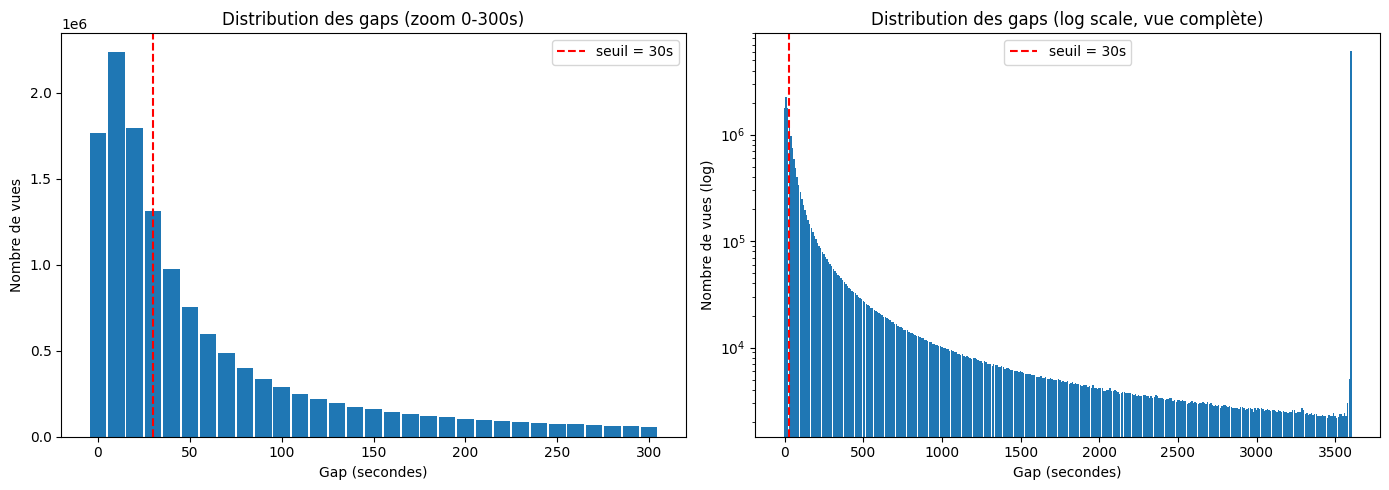

Total users       : 11,206,662
Min n_views       : 1
Max n_views       : 3195
Mean n_views      : 5.9
Percentile  50%   : 2.0
Percentile  90%   : 12.0
Percentile  95%   : 21.0
Percentile  99%   : 3195.0
Percentile 100%   : 3195.0


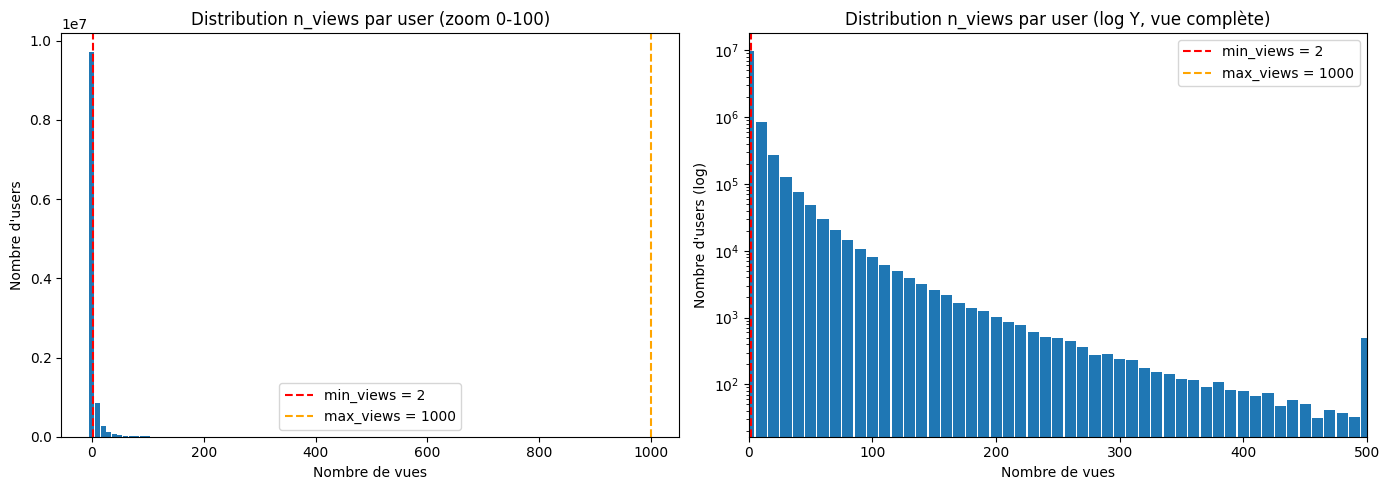

Total sessions    : 21,308,702
Min session_size  : 1
Max session_size  : 330
Mean session_size : 2.4
Percentile  50%   : 1.0
Percentile  90%   : 5.0
Percentile  95%   : 8.0
Percentile  99%   : 330.0
Percentile 100%   : 330.0


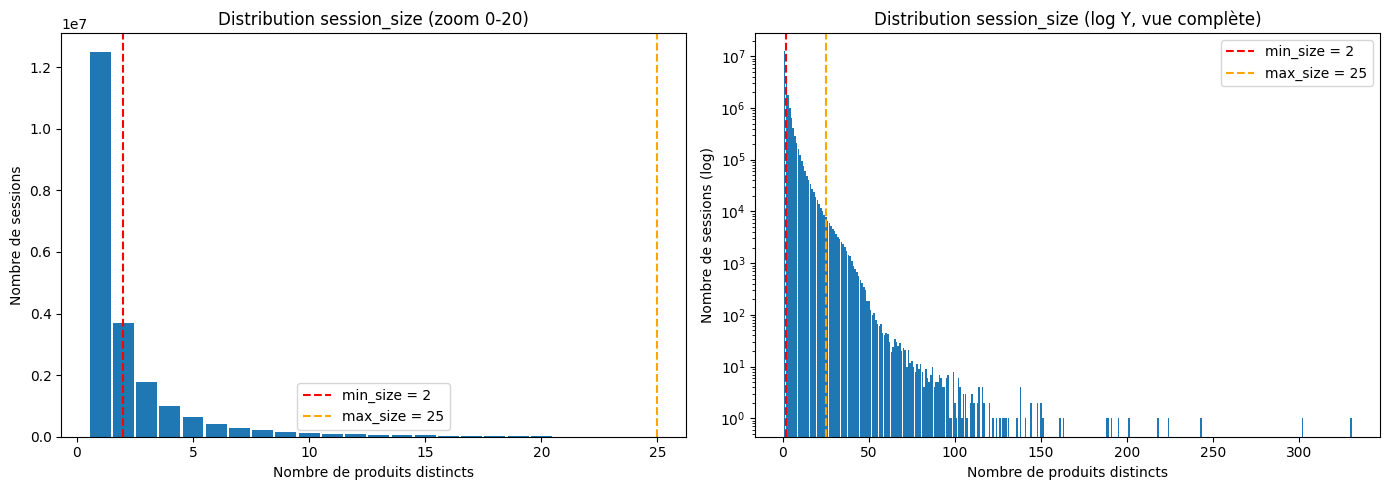

Total edges       : 62,845,565
Min weight        : 1.0
Max weight        : 30316.0
Mean weight       : 2.1
Percentile  50%   : 1.0
Percentile  90%   : 3.0
Percentile  95%   : 5.0
Percentile  99%   : 30316.0
Percentile 100%   : 30316.0


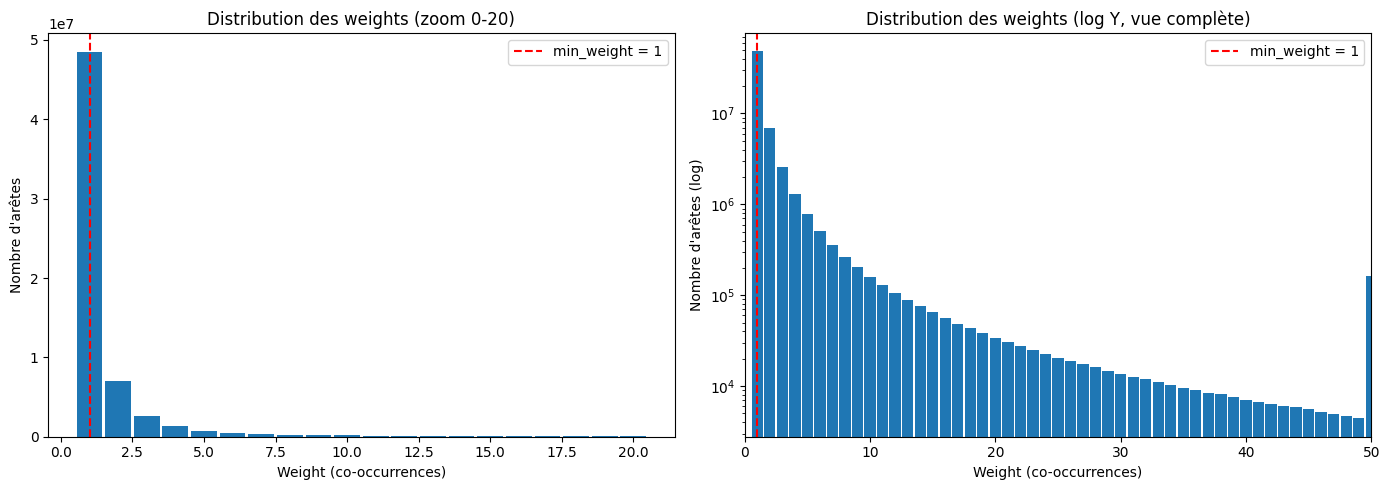

In [0]:
df_customer = get_customer(spark, customer_shortname="maisons-du-monde")
customer_rows = df_customer.collect()
customer_ids = [row["customerId"] for row in customer_rows]
db_names = [row["db_name"] for row in customer_rows]

df_products = get_products(spark, db_names)

start_date = date(2026, 1, 1)
end_date = date(2026, 5, 1)
cutoff_val = end_date - timedelta(days=15)
cutoff_train = end_date - timedelta(days=30)
assert start_date < cutoff_train < cutoff_val < end_date

df_views = get_views(spark, customer_ids, start_date, end_date)

#explore_dedup_views(df_views, bucket_size=10, cap=3600, min_gap_seconds=30)
#explore_filter_users(df_views, min_views=2, max_views=1000, bucket_size=10, cap=500)

df_sessionized = sessionize_views(df_views)

#inspect_sessions_filter_impact(df_sessionized, df_products, min_size=2, max_size=25, reason_filter="too_large").show(5, truncate=False)

#explore_filter_sessions(df_sessionized, min_size=2, max_size=25)

df_edges = build_co_view_edges(df_sessionized)
#explore_filter_edges(df_edges, min_weight=1, bucket_size=1, cap=50)
#explore_isolated_nodes_by_degree(df_edges, min_weight=2)

In [0]:
# ─── Catalogue : total vs actifs ───
df_catalog_full = (
    spark.table("mirakl_ai.ds_etl_prod.t2s_mongo_product_0_current")
    .filter(F.col("db_name").isin(db_names) & (F.col("parentId") == -1))
)
n_total = df_catalog_full.count()
n_active = df_products.count()

# ─── Tracking brut (df_views) ───
n_views = df_views.count()
n_viewed_products = df_views.select("internalId").distinct().count()
n_users = df_views.select("userId").distinct().count()
n_sessions = df_sessionized.select("userId", "session_id").distinct().count()

# ─── Graphe avant tout filtre, mais comparable au pipeline ───
# Le pipeline applique systématiquement df_views.join(df_products, ...) avant sessionize.
# On reproduit ici la même chose pour avoir une référence cohérente.
df_views_active = df_views.join(df_products.select("internalId"), on="internalId", how="inner")
df_sessionized_active = sessionize_views(df_views_active)
df_edges_active = build_co_view_edges(df_sessionized_active)

n_edges_raw = df_edges_active.count()
n_nodes_raw = (
    df_edges_active.select(F.col("product_A").alias("node"))
    .union(df_edges_active.select(F.col("product_B").alias("node")))
    .distinct()
    .count()
)

print(f"Produits dans le catalogue                : {n_total:,}")
print(f"Produits actifs (isActive & isOkInstream) : {n_active:,}")
print(f"Part active                               : {n_active / n_total * 100:.1f}%")
print()
print(f"Vues totales (tracking brut)              : {n_views:,}")
print(f"Produits vus (distincts, brut)            : {n_viewed_products:,}")
print(f"Users distincts (brut)                    : {n_users:,}")
print(f"Sessions (brut)                           : {n_sessions:,}")
print(f"Vues moyennes / session                   : {n_views / n_sessions:.2f}")
print(f"Sessions moyennes / user                  : {n_sessions / n_users:.2f}")
print()
print(f"Graphe (actifs uniquement, sans filtre) — nœuds  : {n_nodes_raw:,}")
print(f"Graphe (actifs uniquement, sans filtre) — arêtes : {n_edges_raw:,}")
print(f"Densité (arêtes / nœuds)                         : {n_edges_raw / n_nodes_raw:.2f}")
print(f"Actifs jamais co-vus (isolés)                    : {n_active - n_nodes_raw:,} ({(n_active - n_nodes_raw) / n_active * 100:.1f}%)")

In [0]:
# ─── Heuristiques structurelles sur le graphe brut (actifs, sans filtre) ───
# Réutilise df_edges_active, n_nodes_raw, n_edges_raw calculés dans la cellule précédente.

density = (2 * n_edges_raw) / (n_nodes_raw * (n_nodes_raw - 1))
avg_degree = 2 * n_edges_raw / n_nodes_raw

print(f"Nœuds        : {n_nodes_raw:,}")
print(f"Arêtes       : {n_edges_raw:,}")
print(f"Densité      : {density:.3e}  (= 2E / N(N-1))")
print(f"Degré moyen  : {avg_degree:.2f}  (= 2E / N)")

# Distribution des degrés (histogramme zoom + scatter log-log)
plot_final_degree_distribution(df_edges_active, cap=200)

# Homophilie / heterophilie par catégorie produit
measure_category_homophily(df_edges=df_edges_active, customer_ids=customer_ids)

In [0]:
# ─── Top nœuds par degré (graphe brut, actifs uniquement) ───
df_degrees = (
    df_edges_active.select(F.col("product_A").alias("internalId"))
    .union(df_edges_active.select(F.col("product_B").alias("internalId")))
    .groupBy("internalId")
    .agg(F.count("*").alias("degree"))
)

print("Top 5 nœuds par degré :")
(
    df_degrees
    .join(df_products, on="internalId", how="left")
    .orderBy(F.col("degree").desc())
    .select("internalId", "degree", "name", "imageUrl")
    .show(5, truncate=False)
)

# ─── Top arêtes par poids ───
df_products_A = df_products.select(
    F.col("internalId").alias("product_A"),
    F.col("name").alias("name_A"),
    F.col("imageUrl").alias("imageUrl_A"),
)
df_products_B = df_products.select(
    F.col("internalId").alias("product_B"),
    F.col("name").alias("name_B"),
    F.col("imageUrl").alias("imageUrl_B"),
)

print("Top 5 arêtes par poids :")
(
    df_edges_active
    .orderBy(F.col("weight").desc())
    .limit(5)
    .join(df_products_A, on="product_A", how="left")
    .join(df_products_B, on="product_B", how="left")
    .select(
        "product_A", "name_A", "imageUrl_A",
        "product_B", "name_B", "imageUrl_B",
        "weight", "raw_count",
    )
    .show(5, truncate=False)
)

In [0]:
# ─── Inspection visuelle d'une session too_large : URLs cliquables ───
from IPython.display import display, HTML
import matplotlib.pyplot as plt

# Taille exacte de la session too_large a piocher (doit etre > 25)
target_size = 30
# (variante "fourchette" : remplace la ligne du filter ci-dessous par :)
#   .filter((F.col("session_size") >= 30) & (F.col("session_size") <= 50))

candidates = (
    df_sessionized
    .groupBy("userId", "session_id")
    .agg(F.countDistinct("internalId").alias("session_size"))
    .filter(F.col("session_size") == target_size)
    .orderBy(F.rand())
    .limit(1)
    .collect()
)
if not candidates:
    raise ValueError(f"Aucune session de taille {target_size} trouvee.")

row = candidates[0]
user_id, session_id, size = row["userId"], row["session_id"], row["session_size"]
print(f"Session piochee : ({user_id}, {session_id}) — taille={size}\n")

session_rows = (
    df_sessionized
    .filter((F.col("userId") == user_id) & (F.col("session_id") == session_id))
    .join(df_products, on="internalId", how="left")
    .orderBy("emitted")
    .select("emitted", "internalId", "name", "imageUrl")
    .collect()
)

html_parts = ["<ol style='font-family:monospace; line-height:1.5'>"]
for r in session_rows:
    url = r["imageUrl"]
    name = (r["name"] or "(sans nom)").replace("<", "&lt;").replace(">", "&gt;")
    ts = r["emitted"]
    if url:
        html_parts.append(
            f'<li>[{ts}] {name} — '
            f'<a href="{url}" target="_blank" rel="noopener">{url}</a></li>'
        )
    else:
        html_parts.append(f'<li>[{ts}] {name} — <em>(pas d\'image)</em></li>')
html_parts.append("</ol>")
display(HTML("".join(html_parts)))

# ─── Distribution des categories vues dans la session ───
df_categories = (
    spark.table("mirakl_ai.ds_artemis_prod.best_fit_cat_products")
    .filter(F.col("customer_id").isin(customer_ids))
    .select(
        F.col("internalId").cast("bigint"),
        "category_selected",
        "category_name_selected",
    )
)

cat_distribution = (
    df_sessionized
    .filter((F.col("userId") == user_id) & (F.col("session_id") == session_id))
    .join(df_categories, on="internalId", how="left")
    .groupBy("category_selected", "category_name_selected")
    .agg(
        F.count("*").alias("n_views"),
        F.countDistinct("internalId").alias("n_distinct_products"),
    )
    .orderBy(F.desc("n_views"))
)

cat_pdf = cat_distribution.toPandas()
cat_pdf["category_name_selected"] = cat_pdf["category_name_selected"].fillna("(non categorise)")
cat_pdf = cat_pdf.head(20)  # top 20 categories

fig, ax = plt.subplots(figsize=(10, max(3.5, 0.45 * len(cat_pdf))))
y_pos = range(len(cat_pdf))

bars = ax.barh(y_pos, cat_pdf["n_views"], color="#4C72B0", edgecolor="white")
ax.set_yticks(y_pos)
ax.set_yticklabels(cat_pdf["category_name_selected"])
ax.invert_yaxis()  # categorie max en haut

ax.set_xlabel("Nombre de vues")
ax.set_title(
    f"Distribution des categories — session taille={size}\n"
    f"(user={str(user_id)[:8]}..., session={str(session_id)[:8]}...)",
    fontsize=11,
)

xmax = cat_pdf["n_views"].max()
for i, (views, distinct) in enumerate(zip(cat_pdf["n_views"], cat_pdf["n_distinct_products"])):
    ax.text(
        views + xmax * 0.01, i,
        f" {views} vues  ({distinct} prod. uniques)",
        va="center", fontsize=9,
    )

ax.set_xlim(0, xmax * 1.35)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

# ─── Statistiques sur les intervalles entre vues consecutives ───
import statistics

emitted_list = [r["emitted"] for r in session_rows]
if len(emitted_list) >= 2:
    gaps_seconds = [
        (emitted_list[i + 1] - emitted_list[i]).total_seconds()
        for i in range(len(emitted_list) - 1)
    ]
    print(f"\nIntervalles entre vues consecutives (en secondes) :")
    print(f"  Nb intervalles  : {len(gaps_seconds)}")
    print(f"  Min             : {min(gaps_seconds):.2f}")
    print(f"  Max             : {max(gaps_seconds):.2f}")
    print(f"  Moyenne         : {statistics.mean(gaps_seconds):.2f}")
    print(f"  Mediane         : {statistics.median(gaps_seconds):.2f}")
    if len(gaps_seconds) >= 2:
        print(f"  Ecart-type (s)  : {statistics.stdev(gaps_seconds):.2f}")
        print(f"  Variance (s^2)  : {statistics.variance(gaps_seconds):.2f}")
    else:
        print("  Ecart-type / variance : N/A (un seul intervalle)")
else:
    print("\nPas assez de vues pour calculer un intervalle (>= 2 requis).")

In [0]:
# ─── Inspection visuelle d'une session de taille donnee ───
from IPython.display import display, HTML

# Taille exacte de la session a piocher
target_size = 10
# (variante "fourchette" : remplace la ligne du filter ci-dessous par :)
#   .filter((F.col("session_size") >= 5) & (F.col("session_size") <= 15))

candidates = (
    df_sessionized
    .groupBy("userId", "session_id")
    .agg(F.countDistinct("internalId").alias("session_size"))
    .filter(F.col("session_size") == target_size)
    .orderBy(F.rand())
    .limit(1)
    .collect()
)
if not candidates:
    raise ValueError(f"Aucune session de taille {target_size} trouvee.")

row = candidates[0]
user_id, session_id, size = row["userId"], row["session_id"], row["session_size"]
print(f"Session piochee : ({user_id}, {session_id}) — taille={size}\n")

session_rows = (
    df_sessionized
    .filter((F.col("userId") == user_id) & (F.col("session_id") == session_id))
    .join(df_products, on="internalId", how="left")
    .orderBy("emitted")
    .select("emitted", "internalId", "name", "imageUrl")
    .collect()
)

html_parts = ["<ol style='font-family:monospace; line-height:1.5'>"]
for r in session_rows:
    url = r["imageUrl"]
    name = (r["name"] or "(sans nom)").replace("<", "&lt;").replace(">", "&gt;")
    ts = r["emitted"]
    if url:
        html_parts.append(
            f'<li>[{ts}] {name} — '
            f'<a href="{url}" target="_blank" rel="noopener">{url}</a></li>'
        )
    else:
        html_parts.append(f'<li>[{ts}] {name} — <em>(pas d\'image)</em></li>')
html_parts.append("</ol>")
display(HTML("".join(html_parts)))

# ─── Distribution des categories vues dans la session ───
import matplotlib.pyplot as plt

df_categories = (
    spark.table("mirakl_ai.ds_artemis_prod.best_fit_cat_products")
    .filter(F.col("customer_id").isin(customer_ids))
    .select(
        F.col("internalId").cast("bigint"),
        "category_selected",
        "category_name_selected",
    )
)

cat_distribution = (
    df_sessionized
    .filter((F.col("userId") == user_id) & (F.col("session_id") == session_id))
    .join(df_categories, on="internalId", how="left")
    .groupBy("category_selected", "category_name_selected")
    .agg(
        F.count("*").alias("n_views"),
        F.countDistinct("internalId").alias("n_distinct_products"),
    )
    .orderBy(F.desc("n_views"))
)

cat_pdf = cat_distribution.toPandas()
cat_pdf["category_name_selected"] = cat_pdf["category_name_selected"].fillna("(non categorise)")
cat_pdf = cat_pdf.head(20)  # top 20 categories

fig, ax = plt.subplots(figsize=(10, max(3.5, 0.45 * len(cat_pdf))))
y_pos = range(len(cat_pdf))

bars = ax.barh(y_pos, cat_pdf["n_views"], color="#4C72B0", edgecolor="white")
ax.set_yticks(y_pos)
ax.set_yticklabels(cat_pdf["category_name_selected"])
ax.invert_yaxis()  # categorie max en haut

ax.set_xlabel("Nombre de vues")
ax.set_title(
    f"Distribution des categories — session taille={size}\n"
    f"(user={str(user_id)[:8]}..., session={str(session_id)[:8]}...)",
    fontsize=11,
)

# Annotations : n_views (n_distinct_products produits uniques)
xmax = cat_pdf["n_views"].max()
for i, (views, distinct) in enumerate(zip(cat_pdf["n_views"], cat_pdf["n_distinct_products"])):
    ax.text(
        views + xmax * 0.01, i,
        f" {views} vues  ({distinct} prod. uniques)",
        va="center", fontsize=9,
    )

ax.set_xlim(0, xmax * 1.35)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

# ─── Statistiques sur les intervalles entre vues consecutives ───
import statistics

emitted_list = [r["emitted"] for r in session_rows]
if len(emitted_list) >= 2:
    gaps_seconds = [
        (emitted_list[i + 1] - emitted_list[i]).total_seconds()
        for i in range(len(emitted_list) - 1)
    ]
    print(f"\nIntervalles entre vues consecutives (en secondes) :")
    print(f"  Nb intervalles  : {len(gaps_seconds)}")
    print(f"  Min             : {min(gaps_seconds):.2f}")
    print(f"  Max             : {max(gaps_seconds):.2f}")
    print(f"  Moyenne         : {statistics.mean(gaps_seconds):.2f}")
    print(f"  Mediane         : {statistics.median(gaps_seconds):.2f}")
    if len(gaps_seconds) >= 2:
        print(f"  Ecart-type (s)  : {statistics.stdev(gaps_seconds):.2f}")
        print(f"  Variance (s^2)  : {statistics.variance(gaps_seconds):.2f}")
    else:
        print("  Ecart-type / variance : N/A (un seul intervalle)")
else:
    print("\nPas assez de vues pour calculer un intervalle (>= 2 requis).")

In [ ]:
# ─── Distribution categorielle : 100 sessions COURTES vs 100 sessions LONGUES ───
# Pour chaque groupe on regarde :
#   1) la distribution du nombre de categories distinctes vues par session
#   2) les categories dominantes (cumul des vues sur l'echantillon)
# Les vues non categorisees sont exclues.
import matplotlib.pyplot as plt

N_SESSIONS = 100    # nb de sessions echantillonnees par groupe
SHORT_SIZE = 3      # sessions courtes : session_size <= SHORT_SIZE
LONG_SIZE  = 25     # sessions longues : session_size >= LONG_SIZE
TOP_N      = 15     # categories affichees par groupe

df_categories = (
    spark.table("mirakl_ai.ds_artemis_prod.best_fit_cat_products")
    .filter(F.col("customer_id").isin(customer_ids))
    .select(
        F.col("internalId").cast("bigint"),
        "category_name_selected",
    )
)

session_sizes = (
    df_sessionized
    .groupBy("userId", "session_id")
    .agg(F.countDistinct("internalId").alias("session_size"))
)

def sample_sessions(condition, n):
    """Echantillonne aleatoirement n sessions verifiant `condition`.
    Sur serverless on ne peut pas .cache() ; on materialise le petit echantillon
    cote driver pour figer le tirage de F.rand() sur les actions suivantes."""
    df = (
        session_sizes
        .filter(condition)
        .orderBy(F.rand())
        .limit(n)
        .select("userId", "session_id")
    )
    return spark.createDataFrame(df.collect(), df.schema)

def analyze(sample_df):
    """Retourne (cats_per_session_pdf, dominant_pdf, n_sessions) pour l'echantillon.
    Exclut les vues non categorisees."""
    views_cat = (
        df_sessionized
        .join(sample_df, on=["userId", "session_id"], how="inner")
        .join(df_categories, on="internalId", how="inner")
        .filter(F.col("category_name_selected").isNotNull())
    )
    cats_per_session = (
        views_cat
        .groupBy("userId", "session_id")
        .agg(F.countDistinct("category_name_selected").alias("n_categories"))
        .toPandas()
    )
    dominant = (
        views_cat
        .groupBy("category_name_selected")
        .agg(
            F.count("*").alias("n_views"),
            F.countDistinct("internalId").alias("n_distinct_products"),
            F.countDistinct(F.concat_ws("|", "userId", "session_id")).alias("n_sessions"),
        )
        .orderBy(F.desc("n_views"))
        .toPandas()
    )
    return cats_per_session, dominant, sample_df.count()

short_sample = sample_sessions(F.col("session_size") <= SHORT_SIZE, N_SESSIONS)
long_sample  = sample_sessions(F.col("session_size") >= LONG_SIZE,  N_SESSIONS)

short_cats, short_dom, n_short = analyze(short_sample)
long_cats,  long_dom,  n_long  = analyze(long_sample)

# ─── Resume ───
def summarize(cats_pdf, dom_pdf, label, n_sessions):
    total_views = dom_pdf["n_views"].sum()
    print(f"  {label}")
    print(f"    Sessions echantillonnees : {n_sessions}")
    print(f"    Vues cumulees            : {total_views:,}")
    print(f"    Categories distinctes    : {len(dom_pdf)}")
    if len(cats_pdf):
        print(f"    Cat. / session (moy.)    : {cats_pdf['n_categories'].mean():.1f}")
        print(f"    Cat. / session (mediane) : {cats_pdf['n_categories'].median():.0f}")
        print(f"    Cat. / session (max)     : {cats_pdf['n_categories'].max()}")
    if total_views:
        print(f"    Part top 1 categorie     : {dom_pdf['n_views'].iloc[0] / total_views * 100:.1f}%")
        print(f"    Part top 3 categories    : {dom_pdf['n_views'].head(3).sum() / total_views * 100:.1f}%")

print("=" * 60)
print("COMPARAISON CATEGORIELLE : sessions courtes vs longues")
print("=" * 60)
summarize(short_cats, short_dom, f"COURTES (<= {SHORT_SIZE} prod.)", n_short)
print()
summarize(long_cats,  long_dom,  f"LONGUES (>= {LONG_SIZE} prod.)",  n_long)
print("=" * 60)

# ─── Plots : 2 lignes (courtes / longues) x 2 colonnes (distribution / dominantes) ───
fig, axes = plt.subplots(2, 2, figsize=(16, 2 * max(4, 0.45 * TOP_N)))

groups = [
    (axes[0], short_cats, short_dom, f"COURTES (<= {SHORT_SIZE} prod.)", "#4C72B0", n_short),
    (axes[1], long_cats,  long_dom,  f"LONGUES (>= {LONG_SIZE} prod.)",  "#C44E52", n_long),
]

for (ax_dist, ax_dom), cats_pdf, dom_pdf, label, color, n_sessions in groups:
    # Distribution du nb de categories par session.
    if len(cats_pdf):
        counts = cats_pdf["n_categories"].value_counts().sort_index()
        ax_dist.bar(counts.index, counts.values, color=color, edgecolor="white", width=0.9)
        ax_dist.set_xticks(counts.index)
    ax_dist.set_xlabel("Nombre de categories distinctes dans la session")
    ax_dist.set_ylabel("Nombre de sessions")
    ax_dist.set_title(f"{label} — distribution cat./session ({n_sessions} sessions)")
    ax_dist.spines["top"].set_visible(False)
    ax_dist.spines["right"].set_visible(False)
    ax_dist.grid(axis="y", linestyle="--", alpha=0.4)

    # Categories dominantes.
    top = dom_pdf.head(TOP_N).iloc[::-1]  # plus grande en haut
    y_pos = range(len(top))
    ax_dom.barh(y_pos, top["n_views"], color=color, edgecolor="white")
    ax_dom.set_yticks(y_pos)
    ax_dom.set_yticklabels(top["category_name_selected"])
    ax_dom.set_xlabel("Nombre de vues (cumulees sur l'echantillon)")
    ax_dom.set_title(f"{label} — categories dominantes (top {TOP_N})")
    xmax = top["n_views"].max() if len(top) else 1
    for i, (v, d, ns) in enumerate(zip(top["n_views"], top["n_distinct_products"], top["n_sessions"])):
        ax_dom.text(v + xmax * 0.01, i, f" {v} vues  ({d} prod., {ns} sess.)", va="center", fontsize=8)
    ax_dom.set_xlim(0, xmax * 1.45)
    ax_dom.spines["top"].set_visible(False)
    ax_dom.spines["right"].set_visible(False)
    ax_dom.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()


In [ ]:
USE_DEDUP_VIEWS = False
USE_FILTER_USERS = False
USE_FILTER_SESSIONS = True
USE_FILTER_EDGES = True

if USE_DEDUP_VIEWS:
    df_views = dedup_views(df_views, min_gap_seconds=30)

if USE_FILTER_USERS:
    df_views = filter_users(df_views, min_views=2, max_views=1000)

df_sessionized = sessionize_views(df_views.join(df_products, on="internalId", how="inner"))

if USE_FILTER_SESSIONS:
    df_sessionized = filter_sessions(df_sessionized, min_size=2, max_size=25)

df_split = split_sessions(df_sessionized, cutoff_train=cutoff_train, cutoff_val=cutoff_val)

def build_and_filter(df_subset, df_train_edges=None):
    edges = build_co_view_edges(df_subset)
    if df_train_edges is not None:
        edges = remove_train_edges(edges, df_train_edges)
    if USE_FILTER_EDGES:
        edges = filter_edges(edges, min_weight=2)
    return edges

df_train_edges = build_and_filter(df_split.filter(F.col("split") == "train"))
df_val_edges = build_and_filter(df_split.filter(F.col("split") == "val"), df_train_edges)
df_test_edges = build_and_filter(df_split.filter(F.col("split") == "test"), df_train_edges)

def count_nodes(df_edges: DataFrame) -> int:
    return (
        df_edges.select(F.col("product_A").alias("node"))
        .union(df_edges.select(F.col("product_B").alias("node")))
        .distinct()
        .count()
    )

all_edges = df_train_edges.union(df_val_edges).union(df_test_edges)
total_nodes = count_nodes(all_edges)

print(f"Filters: dedup={USE_DEDUP_VIEWS} | users={USE_FILTER_USERS} | sessions={USE_FILTER_SESSIONS} | norm={USE_SESSION_WEIGHT_NORM} | edges={USE_FILTER_EDGES}")
print(f"Total nodes: {total_nodes}")
print(f"Train  — edges: {df_train_edges.count()}")
print(f"Val    — edges: {df_val_edges.count()}")
print(f"Test   — edges: {df_test_edges.count()}")


#plot_final_degree_distribution(all_edges, cap=200)

measure_category_homophily(df_edges=all_edges, customer_ids=customer_ids)


# Filtrage du bruit dans le tracking

Avant de construire le graphe de co-views, on applique 4 filtres séquentiels pour éliminer le bruit du tracking brut.

## Filtre 1 — Dedup des vues rapprochées

**Problème** : Le tracking enregistre un event à chaque chargement de page. Un refresh, un clic sur une variante ou un retour arrière génèrent des vues en doublon qui ne représentent pas des intentions de navigation distinctes.

**Règle** : Pour un même `(userId, internalId)`, si deux vues sont espacées de moins de **30 secondes**, on supprime la seconde.

**Exemple** :

| emitted  | userId | internalId | gap  | gardé ? |
|----------|--------|------------|------|---------|
| 10:00:00 | U1     | P42        | NULL | ✅ (1ère vue) |
| 10:00:08 | U1     | P42        | 8s   | ❌ (refresh) |
| 10:00:22 | U1     | P42        | 14s  | ❌ (variante) |
| 10:05:00 | U1     | P42        | 278s | ✅ (retour intentionnel) |

---

## Filtre 2 — Exclusion des users extrêmes

**Problème** : Les bots et crawlers parcourent le catalogue systématiquement (milliers de vues) et créent des co-views artificielles. À l'inverse, un user avec 1-2 vues sur toute la période n'apporte aucun signal.

**Règle** : On garde uniquement les users ayant entre **3 et 5 000 vues** sur la période.

**Exemple** :

| userId | n_views | verdict |
|--------|---------|---------|
| U1     | 1       | ❌ Pas assez de signal |
| U2     | 87      | ✅ User normal |
| U3     | 412     | ✅ User actif |
| U4     | 12 300  | ❌ Probablement un bot |

---

## Filtre 3 — Sessions de taille aberrante

**Problème** : Une session de 1 produit génère 0 paires (inutile). Une session de N produits génère N×(N-1)/2 paires — l'explosion est combinatoire. Une session de 200 produits (scroll infini, bot) crée 19 900 paires dont la majorité est du bruit.

**Règle** : On garde les sessions contenant entre **2 et 50 produits distincts**.

**Exemple** :

| userId | session_id | produits distincts | paires générées | verdict |
|--------|------------|--------------------|-----------------|---------|
| U1     | 1          | 1                  | 0               | ❌ Aucune paire |
| U1     | 2          | 8                  | 28              | ✅ Session normale |
| U2     | 1          | 45                 | 990             | ✅ Limite acceptable |
| U3     | 1          | 150                | 11 175          | ❌ Explosion combinatoire |

---

## Filtre 5 — Co-views accidentelles (poids minimum)

**Problème** : Deux produits co-vus 1 ou 2 fois seulement — c'est probablement du hasard de navigation. Ces edges à faible poids représentent la majorité du graphe mais portent le moins de signal.

**Règle** : On ne garde que les edges avec un poids ≥ **3** (co-vus dans au moins 3 sessions distinctes).

**Exemple** :

| product_A | product_B | weight | verdict |
|-----------|-----------|--------|---------|
| Canapé velours | Coussin jaune | 47 | ✅ Signal fort (souvent co-vus) |
| Table basse | Lampe design | 3 | ✅ Signal faible mais suffisant |
| Étagère murale | Tondeuse gazon | 1 | ❌ Co-vue accidentelle |